In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/ML_Scratch

/content/drive/MyDrive/ML_Scratch


In [ ]:
!dir

build  Loss_Functions  ML_Scratch.egg-info  models  Optimizers	setup.py


In [ ]:
!pip install .

Processing /content/drive/MyDrive/ML_Scratch
  Preparing metadata (setup.py) ... done
  Created wheel for ML_Scratch: filename=ML_Scratch-0.1-py3-none-any.whl size=17898 sha256=8dcaddc58946b077499549fa91620b8b49775f73e7beb6706c40a2c73395923b
  Stored in directory: /tmp/pip-ephem-wheel-cache-kwv3adzi/wheels/ec/79/c9/4d7d10df97932c871a51b14cf6330718c7e29048f909474d5a
Successfully built ML_Scratch


In [ ]:
from models import linear_regression, linear_classification, Nonlinear_regression, Nonlinear_classification, MLP, DT_classifier, DT_Regressor, SVM
from Optimizers import Optimizer, MLP_Optimizer
import numpy as np
import matplotlib.pyplot as plt

## **Testing Regression Model**

**Linear and non Linear Regression**

In [ ]:
x = np.array([1, 2, 3])
N = x.shape[0]
K = 3
Phi = np.zeros((N, K + 1))
print(N)

3


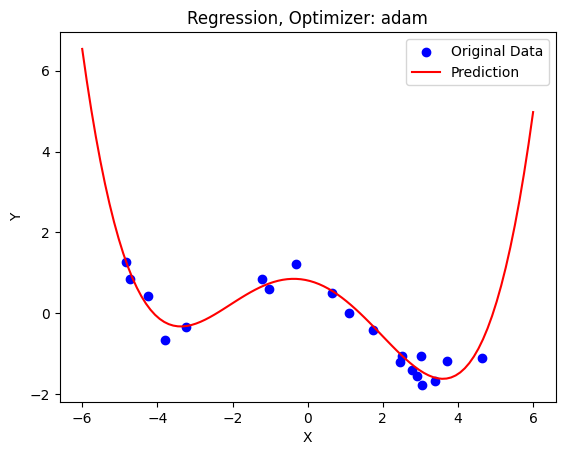

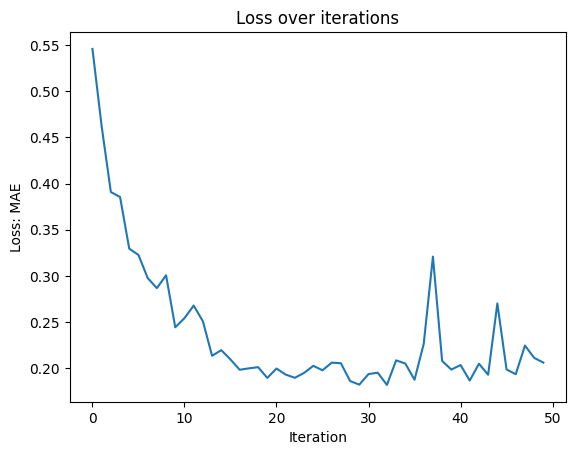

In [ ]:
# Training Data
mu, sigma = 0, 0.2
eps = np.random.normal(mu, sigma, 20).reshape(-1,1)

X = np.random.uniform(-5, 5, size=(1, 20)).reshape(-1,1) # Input Data
Y = - np.sin(X/5) + np.cos(X) + eps # Corresponding Label

# Choose the optimizer from: [GradientDescent, SGD, momentum, rmsprop, adam]
# alpha: Learning Rate
# n_iteration: Number of iterations

optimizer = Optimizer(alpha=0.001, n_iteration=50, optimizer='adam', batch_size = 16)

# Choose the Regression model with Loss Function [MAE, MSE]
# model = linear_regression(optimizer=optimizer, lossfunction = 'MAE')
# model = Nonlinear_regression(optimizer=optimizer, lossfunction = 'MAE', K = 4) # Define the order of polynomial K

model = Nonlinear_regression(optimizer=optimizer, lossfunction = 'MAE', K = 4) # Define the order of polynomial K

# Fitting the model to find optimum parameters and minimize losses
theta, losses = model.best_fit(X, Y)

# Testing
X_new = np.linspace(-6, 6, 100).reshape(-1,1) # generate 100 points uniformly spaced
Y_new = - np.sin(X_new/5) + np.cos(X_new) + np.random.normal(mu, sigma, 100).reshape(-1,1)

# Predictions
predictions = model.predict(X_new) # Evaluation on test data

# Visualizing the results
plt.scatter(X, Y, color='blue', label='Original Data')
plt.plot(X_new, predictions, color='red', label='Prediction')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Regression, Optimizer: {optimizer.optimizer}')
plt.legend()
plt.show()

# Optional: Visualizing the loss over iterations
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel(f'Loss: {model.lossfunction.loss}')
plt.title('Loss over iterations')
plt.show()

**Comparison with Scikit Learn**

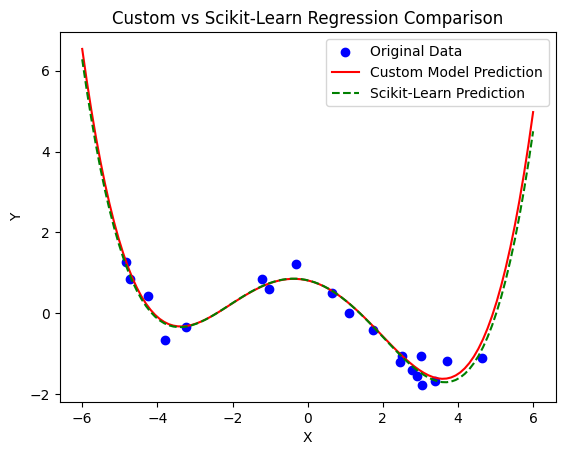

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Generate polynomial features with degree K=4
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

# Train Linear Regression model
model_sklearn = LinearRegression()
model_sklearn.fit(X_poly, Y)


# Predict with the scikit-learn model
X_new_poly = poly.transform(X_new)  # Polynomial transformation for test data
predictions_sklearn = model_sklearn.predict(X_new_poly)

plt.scatter(X, Y, color='blue', label='Original Data')
plt.plot(X_new, predictions, color='red', linestyle='-', label='Custom Model Prediction')
plt.plot(X_new, predictions_sklearn, color='green', linestyle='--', label='Scikit-Learn Prediction')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Custom vs Scikit-Learn Regression Comparison')
plt.legend()
plt.show()

In [ ]:
# Calculate MAE for Custom Model
mae_custom = mean_absolute_error(Y_new, predictions)
mse_custom = mean_squared_error(Y_new, predictions)

# Calculate MAE for Scikit-Learn Model
mae_sklearn = mean_absolute_error(Y_new, predictions_sklearn)
mse_sklearn = mean_squared_error(Y_new, predictions_sklearn)

print(f"Custom Model - MAE: {mae_custom:.4f}, MSE: {mse_custom:.4f}")
print(f"Scikit-Learn Model - MAE: {mae_sklearn:.4f}, MSE: {mse_sklearn:.4f}")

Custom Model - MAE: 0.6292, MSE: 1.4980
Scikit-Learn Model - MAE: 0.5710, MSE: 1.2358


**Decision Tree Regression**

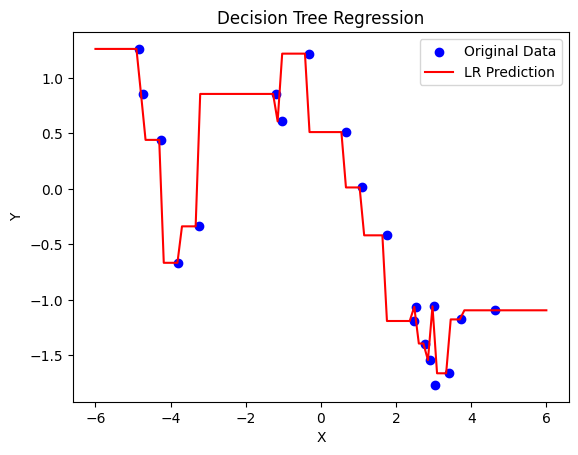

Mean Squared Error on test set: 0.36757628450559143


In [ ]:
model = DT_Regressor(max_depth=7)

# Fit the model to find the best theta (weights)
model.fit(X, Y)

# Making predictions with new unseen data
X_new = np.linspace(-6, 6, 100).reshape(-1,1) # generate 100 points uniformly spaced
Y_new = - np.sin(X_new/5) + np.cos(X_new) + np.random.normal(mu, sigma, 100).reshape(-1,1)
predictions = model.predict(X_new)

# Optional: Visualizing the results
import matplotlib.pyplot as plt
plt.scatter(X, Y, color='blue', label='Original Data')
plt.plot(X_new, predictions, color='red', label='LR Prediction')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Decision Tree Regression')
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error
# Calculate Mean Squared Error (MSE) on the training set
mse = mean_squared_error(Y_new, predictions)
print(f"Mean Squared Error on test set: {mse}")

**Comparison with Scikit Learn**

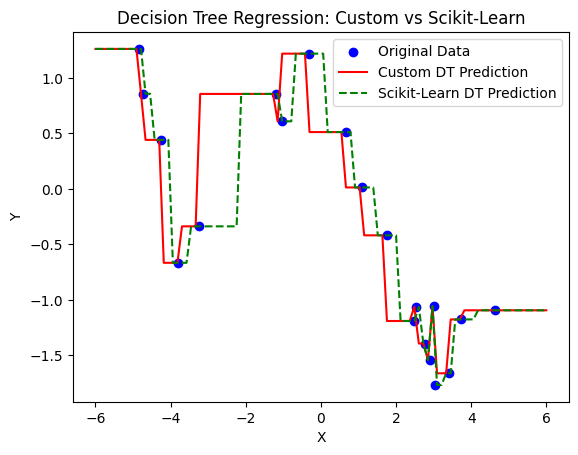

Custom DT Regressor - MSE: 0.3676
Scikit-Learn DT Regressor - MSE: 0.1840


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Create and fit a Decision Tree Regressor
dt_sklearn = DecisionTreeRegressor(max_depth=7)
dt_sklearn.fit(X, Y)

# Make predictions on test data
predictions_sklearn = dt_sklearn.predict(X_new)

# Plotting results
plt.scatter(X, Y, color='blue', label='Original Data')
plt.plot(X_new, predictions, color='red', linestyle='-', label='Custom DT Prediction')
plt.plot(X_new, predictions_sklearn, color='green', linestyle='--', label='Scikit-Learn DT Prediction')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Decision Tree Regression: Custom vs Scikit-Learn')
plt.legend()
plt.show()

# Calculate MSE for Custom Model
mse_custom = mean_squared_error(Y_new, predictions)

# Calculate MSE for Scikit-Learn Model
mse_sklearn = mean_squared_error(Y_new, predictions_sklearn)

print(f"Custom DT Regressor - MSE: {mse_custom:.4f}")
print(f"Scikit-Learn DT Regressor - MSE: {mse_sklearn:.4f}")


## **Testing Classification Models**

**Linear and Non Linear Classification**

Accuracy on test data: 50.00%


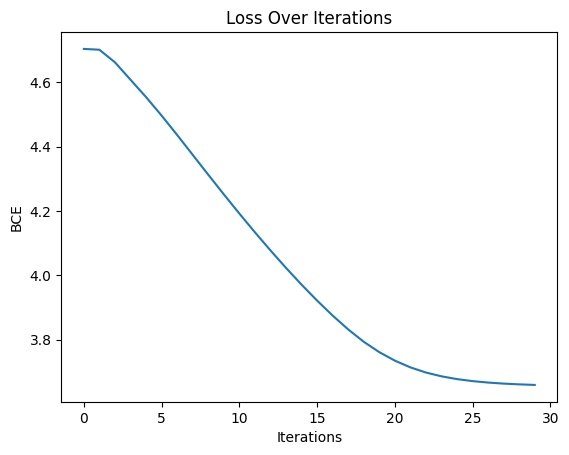

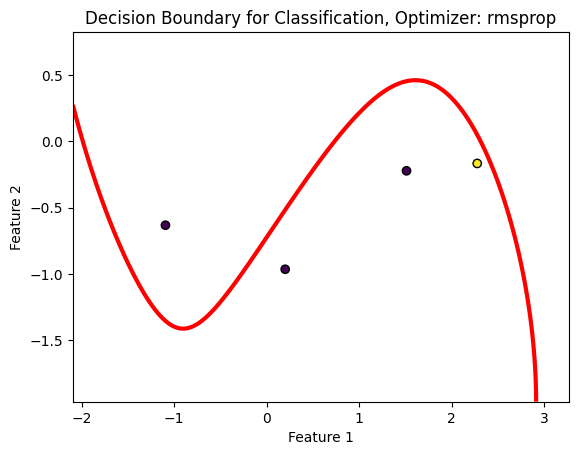

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Creating binary Classification Dataset with two features
X, Y = make_classification(n_samples=12, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=42)

# Split into Train and Test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Choose the optimizer from: [GradientDescent, SGD, momentum, rmsprop, adam]
# alpha: Learning Rate
# n_iteration: Number of iterations

optimizer = Optimizer(alpha=0.001, n_iteration=30, optimizer='rmsprop', batch_size = 16)

# Choose the Classification  model with Loss Function [BCE, ErrorRate, accuracy]
# model = linear_classification(optimizer=optimizer, lossfunction = 'accuracy')
# model = Nonlinear_classification(optimizer=optimizer, lossfunction = 'BCE', K = 4)  # Define the order of polynomial K
model = Nonlinear_classification(optimizer=optimizer, lossfunction = 'BCE', K = 3)

# Fitting the model to find optimum parameters and minimize losses
theta, losses = model.best_fit(X_train, Y_train)

# Step 5: Make Predictions on the Test Set
Y_pred_probs = model.predict(X_test)
Y_pred_classes = model.predict_class(X_test)

# Step 6: Evaluate the Model
accuracy = np.mean(Y_pred_classes == Y_test)
print(f"Accuracy on test data: {accuracy * 100:.2f}%")

plt.plot(losses)
plt.title("Loss Over Iterations")
plt.xlabel("Iterations")
plt.ylabel(f"{model.lossfunction.loss}")
plt.show()

def plot_decision_boundary(X, y, model, resolution=0.01):
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))

    # Flatten the grid to pass through the model
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict probabilities for the grid points
    probs = model.predict(grid).reshape(xx.shape)

    # Plot the decision boundary
    plt.contour(xx, yy, probs, levels=[0.5], linewidths=3, colors='r')

    # Plot the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis')
    plt.title(f"Decision Boundary for Classification, Optimizer: {optimizer.optimizer}")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Now call the function on your test data
plot_decision_boundary(X_test, Y_test, model)

**Decision Tree Classification**

In [ ]:
# Initialize and train decision tree
tree = DT_classifier(max_depth=3)
tree.fit(X_train, Y_train)

# Make predictions
y_pred = tree.predict(X_test)

# Evaluate the accuracy
accuracy = np.sum(y_pred == Y_test) / len(Y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(Y_test)
print(y_pred)

Accuracy: 50.00%
[0 0 0 1]
[0, 1, 1, 1]


In [ ]:
X_train = np.array([[2.0, 1.5], [3.1, 4.0], [1.2, 2.3], [3.5, 3.1], [2.3, 2.9]])
Y_train = np.array([0, 1, 0, 1, 0])

X_test = np.array([[2.5, 1.8], [3.0, 3.5], [1.0, 1.8], [2.1, 2.5]])
Y_test = np.array([0, 1, 0, 0])

# Initialize and train the decision tree
tree.fit(X_train, Y_train)

# Make predictions
Y_pred = tree.predict(X_test)

# Evaluate the accuracy
accuracy = np.sum(Y_pred == Y_test) / len(Y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(Y_test)
print(Y_pred)

Accuracy: 75.00%
[0 1 0 0]
[1, 1, 0, 0]


Accuracy on test data: 50.00%


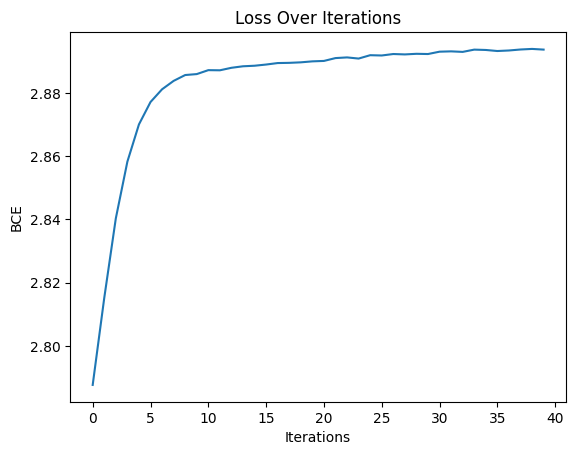

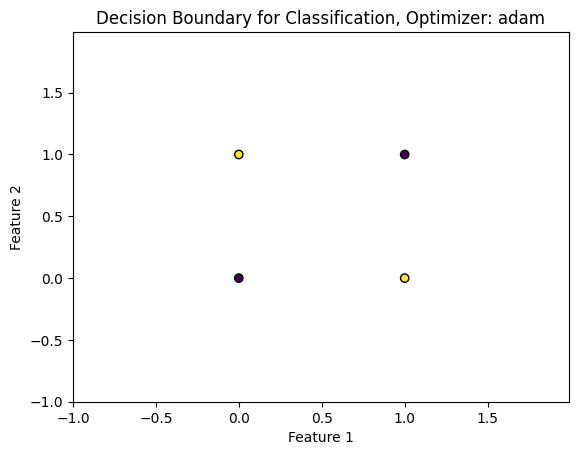

In [ ]:
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
Y = np.array([0, 1, 1, 0])  # Corresponding labels

optimizer = Optimizer(alpha=0.001, n_iteration=40, optimizer='adam', batch_size = 1)
model = Nonlinear_classification(optimizer=optimizer, lossfunction = 'BCE', K = 1)
#model = linear_classification(optimizer=optimizer, lossfunction = 'accuracy')

# Fitting the model to find optimum parameters and minimize losses
theta, losses = model.best_fit(X, Y)

# Step 5: Make Predictions on the Test Set
Y_pred_probs = model.predict(X)
Y_pred_classes = model.predict_class(X)

# Step 6: Evaluate the Model
accuracy = np.mean(Y_pred_classes == Y)
print(f"Accuracy on test data: {accuracy * 100:.2f}%")

plt.plot(losses)
plt.title("Loss Over Iterations")
plt.xlabel("Iterations")
plt.ylabel(f"{model.lossfunction.loss}")
plt.show()

# Now call the function on your test data
plot_decision_boundary(X, Y, model)

## **MLP Testing**

In [ ]:
def plot_decision_boundary(X, y, model, resolution=0.01):
    # Create a mesh grid over the feature space
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))

    # Predict the class for each point in the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.forward(grid_points)
    Z = np.argmax(Z, axis=1)  # Get the class label (0 or 1)

    # Reshape the output to match the grid
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.coolwarm)

    # Scatter plot of actual data points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title('Decision Boundary of MLP')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

def one_hot(y, num_classes):
    one_hot_encoded = np.zeros((y.size, num_classes))
    one_hot_encoded[np.arange(y.size), y] = 1
    return one_hot_encoded

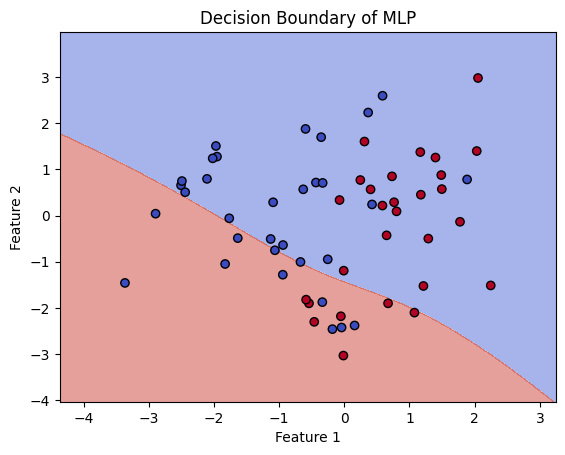

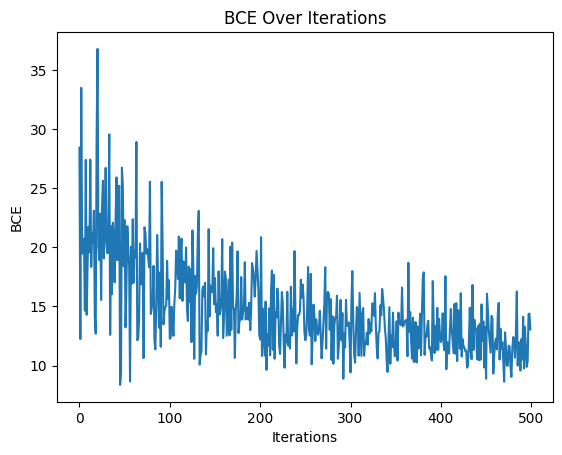

Accuracy on test data: 76.67%


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Creating binary Classification Dataset with two features
X, Y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=42)
Y = Y.reshape(-1, 1)

# Split into Train and Test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
#y_train_oh = one_hot(Y_train, 2)  # One-hot encode the labels (for binary classification)

# Initialize optimizer and loss function
optimizer = MLP_Optimizer(alpha=0.001, n_iteration=500, optimizer="adam", batch_size=16)

# Initialize and train the MLP
model = MLP(input_size=2, hidden_size=10, output_size=2, optimizer=optimizer, lossfunction= 'BCE')
loss = model.best_fit(X_train, Y_train)

Y_pred = model.forward(X_test)
Y_pred = (Y_pred > 0.5).astype(int)  # Apply threshold for binary classification

# Plot the decision boundary for the MLP model
plot_decision_boundary(X_test, Y_test, model)

plt.plot(loss)
plt.xlabel('Iterations')
plt.ylabel(f"{model.lossfunction.loss}")
plt.title(f'{model.lossfunction.loss} Over Iterations')
plt.show()

accuracy = np.mean(Y_pred == Y_test)
print(f"Accuracy on test data: {accuracy * 100:.2f}%")

**Multi Class Classification**

Accuracy on test data: 95.00%


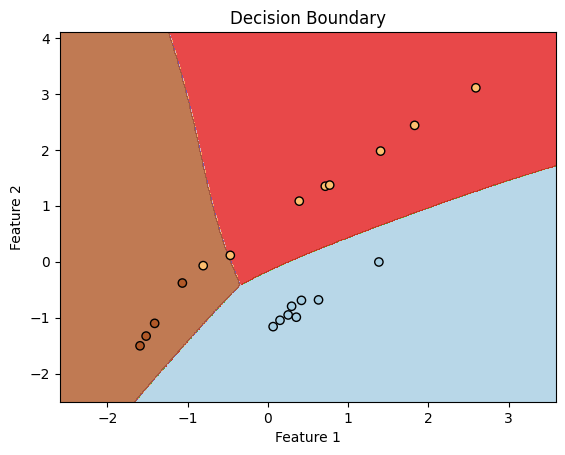

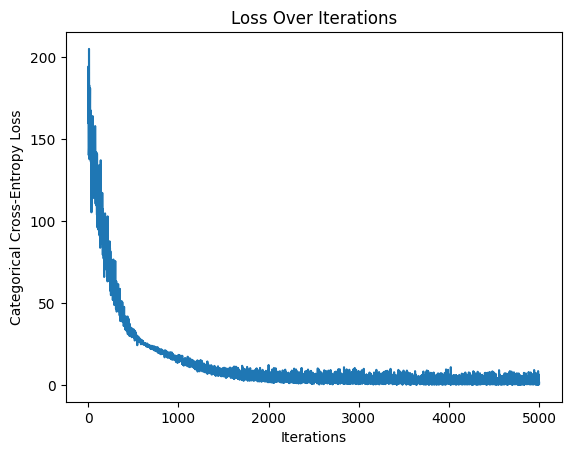

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic multi-class data
X, Y = make_classification(n_samples=100, n_features=2, n_classes=3, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
Y = Y.reshape(-1, 1)

# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)
Y_onehot = encoder.fit_transform(Y)

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_onehot, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP for multi-class classification
optimizer = MLP_Optimizer(alpha=0.001, n_iteration=5000, optimizer="adam", batch_size=32)
model = MLP(input_size=2, hidden_size=20, output_size=3, optimizer=optimizer, lossfunction='BCE')  # CCE: Categorical Cross Entropy

# Train the model
loss = model.best_fit(X_train, Y_train)

# Predict on test set
Y_pred = model.forward(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)  # Convert probabilities to class indices
Y_true_classes = np.argmax(Y_test, axis=1)

# Accuracy
accuracy = np.mean(Y_pred_classes == Y_true_classes)
print(f"Accuracy on test data: {accuracy * 100:.2f}%")

# Plot decision boundary

def plot_decision_boundary(model, X, y):
    """
    Plot the decision boundary of the model.

    Args:
    - model: Trained model with a `forward` method for predictions.
    - X: 2D feature array (n_samples, 2).
    - y: 1D label array.
    """
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.forward(grid)  # Predict over the grid
    Z = np.argmax(Z, axis=1)  # Convert to class predictions
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


plot_decision_boundary(model, X_test, np.argmax(Y_test, axis=1))

plt.plot(loss)
plt.xlabel('Iterations')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.title('Loss Over Iterations')
plt.show()

In [ ]:
# Decision Boundary Plot
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    Z = model.forward(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contour(xx, yy, Z, levels=[0.5], colors="r")  # Decision boundary at 0.5
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=100,  cmap=plt.cm.coolwarm)
    plt.title("Decision Boundary of XOR with MLP")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

[[0]
 [1]
 [1]
 [0]]


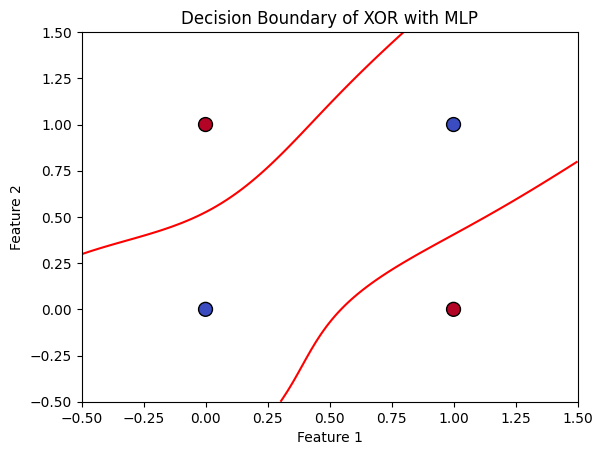

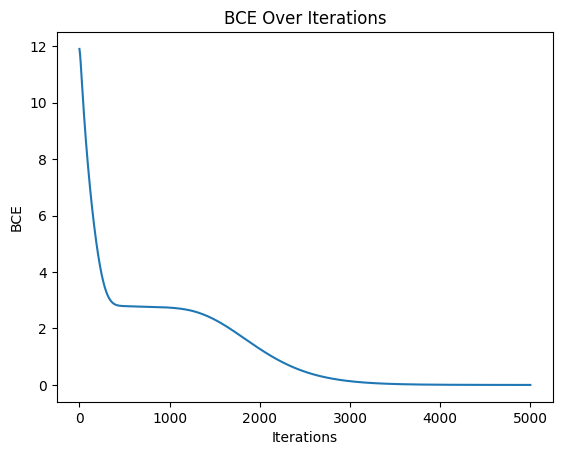

Accuracy on test data: 100.00%


In [ ]:
# XOR Data
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
Y_xor = np.array([[0], [1], [1], [0]])

optimizer = MLP_Optimizer(alpha=0.001, n_iteration=5000, optimizer="adam", batch_size=16)

# Initialize and train the MLP
model = MLP(input_size=2, hidden_size=20, output_size=1, optimizer=optimizer, lossfunction= 'BCE')
loss = model.best_fit(X_xor, Y_xor)

Y_pred = model.forward(X_xor)
Y_pred = (Y_pred > 0.5).astype(int)  # threshold for binary classification
print(Y_pred)

# Plot the decision boundary for the MLP model
plot_decision_boundary(model, X_xor, Y_xor)

plt.plot(loss)
plt.xlabel('Iterations')
plt.ylabel(f"{model.lossfunction.loss}")
plt.title(f'{model.lossfunction.loss} Over Iterations')
plt.show()

accuracy = np.mean(Y_pred == Y_xor)
print(f"Accuracy on test data: {accuracy * 100:.2f}%")

## **SVM**

In [ ]:
Y_train = np.where(Y_train <= 0, -1, 1)
Y_test = np.where(Y_test <= 0, -1, 1)

svm = SVM(R=0.1)
svm.fit(X_train, Y_train)

y_pred = svm.predict(X_test)

accuracy = np.mean(y_pred == Y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 81.67%


In [ ]:
np.random.seed(42)
X_pos = np.random.randn(50, 2) + 1  # Positive class
X_neg = np.random.randn(50, 2) - 1  # Negative class
X = np.vstack((X_pos, X_neg))
y = np.hstack((np.ones(50), -1 * np.ones(50)))

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svm = SVM(R=1.0)
svm.fit(X_train, Y_train)

y_pred = svm.predict(X_test)

accuracy = np.mean(y_pred == Y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 75.00%


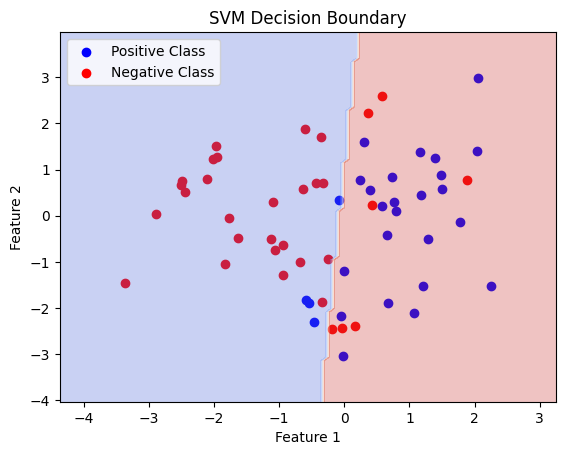

Accuracy: 81.67%


In [ ]:
def plot_decision_boundary(svm, X, y):
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Positive Class')
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Negative Class')

    # Create a grid to plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('SVM Decision Boundary')
    plt.legend()
    plt.show()

plot_decision_boundary(svm, X_test, Y_test)
# Evaluate the accuracy
accuracy = np.mean(Y_test == y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

**Comparison with Scikit Learn**

Accuracy: 81.67%


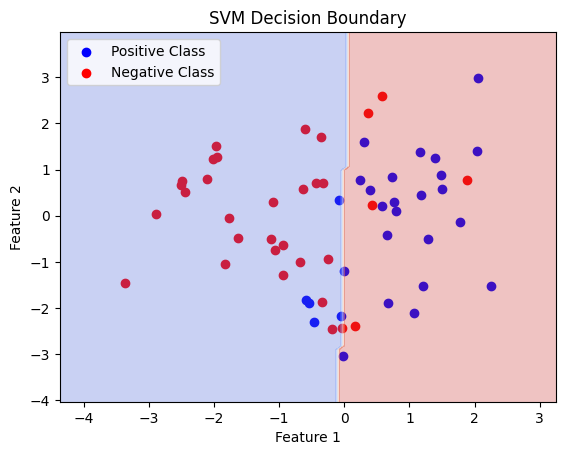

In [ ]:
from sklearn import svm
svc = svm.SVC(kernel='linear', C=10)
svc.fit(X_train, Y_train)
y_pred = svc.predict(X_test)

# Evaluate the accuracy
accuracy = np.mean(Y_test == y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Step 4: Visualize the Decision Boundary
def plot_decision_boundary(svm, X, y):
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Positive Class')
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Negative Class')

    # Create a grid to plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('SVM Decision Boundary')
    plt.legend()
    plt.show()

plot_decision_boundary(svc, X_test, Y_test)